In [1]:

# one of the package managers uv or pip or conda has f*cked up my PATH
import sys
sys.path.append("/home/macbuse/miniconda3/lib/python3.11/site-packages")

import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
import scipy.stats as stats
#never used
#import math

/tmp/ipykernel_8045/2663785651.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  import scipy.stats as stats


---

# Exo 1

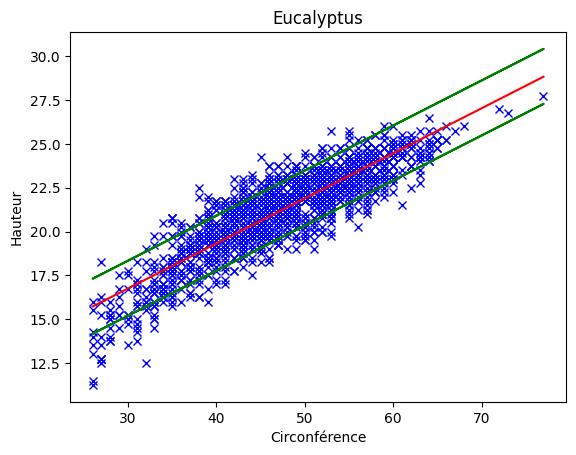

Correlation entre la hauteur et son ajustement affine:  0.8765387831882144
Correlation entre la hauteur et son ajustement affine:  0.8765387831882088
Angle en degrés entre y recentré et x recentré 28.772383472847874


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stat


## Exo 1
c=np.loadtxt("./circ.txt")
h=np.loadtxt("./h.txt")
plt.figure()
plt.title('Eucalyptus')
plt.xlabel('Circonférence')
plt.ylabel('Hauteur')
plt.plot(c,h,'bx')
mc=np.mean(c)
mh=np.mean(h)
a=np.mean((c-mc)*(h-mh))/np.mean((c-mc)*(c-mc))
b=mh-mc*a
x=np.linspace(min(c),max(c),100)
y=x*a+b
plt.plot(x,y,'r')
b1=np.quantile(h-a*c,.1)
b2=np.quantile(h-a*c,.9)
plt.plot(c,a*c+b1,'g')
plt.plot(c,a*c+b2,'g')
plt.show()
hpred=a*c+b
r=np.mean((h-mh)*hpred)/np.sqrt(np.mean((h-mh)**2)*np.mean((hpred-mh)**2))
print('Correlation entre la hauteur et son ajustement affine: ',r)
R=np.mean((h-mh)*(c-mc))/np.sqrt(np.mean((h-mh)**2)*np.mean((c-mc)**2))
print('Correlation entre la hauteur et son ajustement affine: ',R)
print('Angle en degrés entre y recentré et x recentré',np.arccos(R)*180/np.pi)



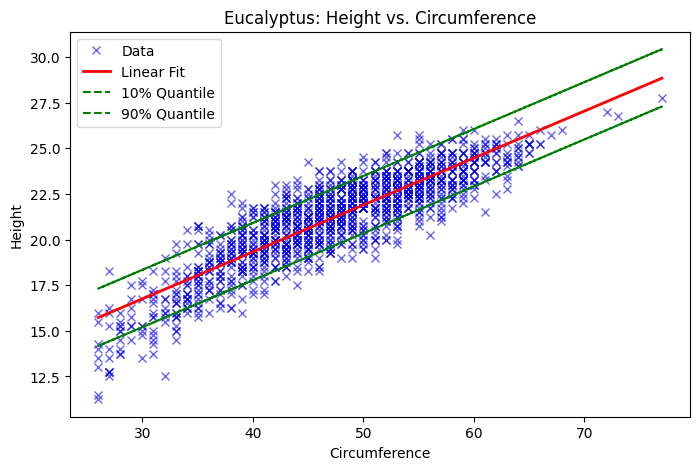

Correlation (R): 0.8765
Angle between centered vectors: 28.77°


In [5]:
simport numpy as np
import matplotlib.pyplot as plt

# 1. Load Data
circ = np.loadtxt("./circ.txt")
height = np.loadtxt("./h.txt")

# 2. Linear Regression (y = ax + b)
# polyfit is more concise for calculating slope (a) and intercept (b)
a, b = np.polyfit(circ, height, 1)

# 3. Calculate Predictions and Correlation
height_pred = a * circ + b
correlation = np.corrcoef(circ, height)[0, 1]
angle_deg = np.degrees(np.arccos(correlation))

# 4. Quantiles for Residuals
residuals = height - (a * circ)
b_low = np.quantile(residuals, 0.1)
b_high = np.quantile(residuals, 0.9)

# 5. Visualization
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title('Eucalyptus: Height vs. Circumference')
ax.set_xlabel('Circumference')
ax.set_ylabel('Height')

# Scatter plot
ax.plot(circ, height, 'bx', label='Data', alpha=0.6)

# Regression lines
x_range = np.linspace(circ.min(), circ.max(), 100)
ax.plot(x_range, a * x_range + b, 'r', linewidth=2, label='Linear Fit')
ax.plot(circ, a * circ + b_low, 'g--', label='10% Quantile')
ax.plot(circ, a * circ + b_high, 'g--', label='90% Quantile')

ax.legend()
plt.show()

# 6. Results
print(f"Correlation (R): {correlation:.4f}")
print(f"Angle between centered vectors: {angle_deg:.2f}°")


---

# Exo 2

### Explication des méthodes utilisées

*   **`stats.t.ppf(q, df)`** : La fonction *Percent Point Function* (inverse de la fonction de répartition). Elle permet de trouver la valeur critique $t$ pour un niveau de confiance donné et un nombre de degrés de liberté ($df$).
*   **`np.sqrt()`** : Calcule la racine carrée.
*   **F-strings (`f"..."`)** : Utilisées pour intégrer les variables directement dans le texte et arrondir les résultats (ex: `:.3f` pour 3 décimales), ce qui est beaucoup plus propre que les concaténations manuelles.

### Ce que ce calcul représente
L'intervalle obtenu permet de déterminer si la différence entre les deux groupes (A et B) est statistiquement significative. Si l'intervalle ne contient pas la valeur **0**, 
on peut généralement rejeter l'hypothèse d'égalité des moyennes au seuil $\alpha$.

In [6]:

import numpy as np
from scipy import stats

# 1. Paramètres et données
n1, n2 = 12, 12
n = n1 + n2
alpha = 0.05

mean_a, std_a = 4.8, 0.36
mean_b, std_b = 5.7, 0.40

# 2. Calcul de l'écart-type combiné (Pooled Standard Deviation)
# Formule : sqrt( ((n1-1)*s1^2 + (n2-1)*s2^2) / (n1+n2-2) )
pooled_std = np.sqrt(((n1 - 1) * std_a**2 + (n2 - 1) * std_b**2) / (n - 2))

# 3. Calcul de la marge d'erreur (Epsilon)
# t_alpha/2 pour n-2 degrés de liberté
t_critique = stats.t.ppf(1 - alpha / 2, n - 2)
erreur_type = np.sqrt(1 / n1 + 1 / n2) * pooled_std
marge_erreur = t_critique * erreur_type

# 4. Calcul de l'intervalle
diff_moyennes = mean_a - mean_b
borne_inf = diff_moyennes - marge_erreur
borne_sup = diff_moyennes + marge_erreur

# 5. Affichage
print(f"Intervalle de confiance à {1-alpha:.0%} : [{borne_inf:.3f} ; {borne_sup:.3f}]")


Intervalle de confiance à 95% : [-1.222 ; -0.578]
